**BDA Project Brazil Ecommerce Forecasting**

1. Data Loading
2. Data Cleaning and Preprocessing
3. Exploratory Data Analysis
4. Regional Demand Analysis
5. Forecasting with ARIMA
6. Machine Learning with Random Forest
7. Model Comparison
8. Conclusion

In [4]:
import pandas as pd

In [6]:
orders = pd.read_csv('df_Orders.csv')
customers = pd.read_csv('df_Customers.csv')
order_items = pd.read_csv('df_OrderItems.csv')
payments = pd.read_csv('df_Payments.csv')
products = pd.read_csv('df_Products.csv')

In [ ]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09
1,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24
2,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08
3,bwJVWupf2keN,EOEsCQ6QlpIg,delivered,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19
4,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,delivered,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18


In [ ]:
orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,9
order_delivered_timestamp,1889
order_estimated_delivery_date,0


In [ ]:
orders['order_status'].value_counts()


,count
order_status,
delivered,87428
shipped,936
canceled,409
processing,273
invoiced,266
unavailable,2
approved,2


In [ ]:
# Keep only delivered orders
orders = orders[orders['order_status'] == 'delivered']

In [ ]:
orders['order_status'].value_counts()

,count
order_status,
delivered,87428


Only delivered orders were retained to ensure that the analysis reflects completed transactions and accurate fulfillment performance.


In [ ]:
# Remove rows with missing delivery timestamps
orders = orders.dropna(subset=['order_delivered_timestamp'])

In [ ]:
orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,9
order_delivered_timestamp,0
order_estimated_delivery_date,0


Observations with missing delivery timestamps were removed to ensure the accuracy of delivery time calculations and fulfillment performance analysis.

In [ ]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_timestamp'] = pd.to_datetime(orders['order_delivered_timestamp'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

In [ ]:
orders.dtypes

,0
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,datetime64[ns]
order_approved_at,object
order_delivered_timestamp,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]


In [ ]:
# Create delivery time in days
orders['delivery_time'] = (orders['order_delivered_timestamp'] - orders['order_purchase_timestamp']).dt.days

In [ ]:
orders[['order_purchase_timestamp', 'order_delivered_timestamp', 'delivery_time']].head()

,order_purchase_timestamp,order_delivered_timestamp,delivery_time
0,2017-10-22 18:57:54,2017-10-26 22:19:52,4
1,2018-06-20 21:40:31,2018-07-03 22:51:22,13
2,2018-02-16 16:19:31,2018-02-27 01:29:50,10
3,2018-08-18 18:04:29,2018-08-27 20:03:51,9
4,2017-12-22 16:44:04,2018-01-05 19:22:49,14


In [ ]:
# Create order month
orders['order_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

# Count orders per month
monthly_orders = orders.groupby('order_month').size()

# Convert to dataframe
monthly_orders = monthly_orders.reset_index(name='order_count')

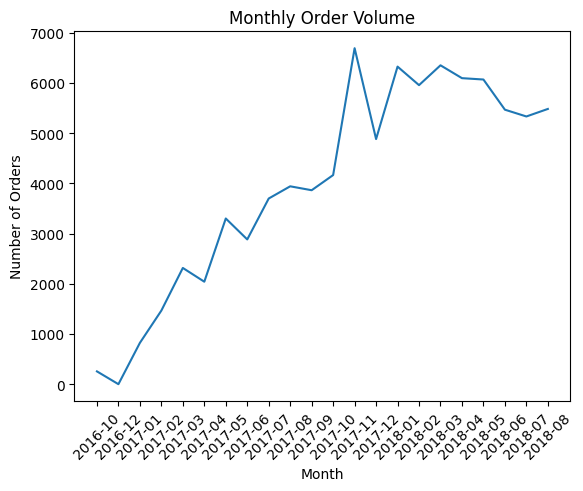

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(monthly_orders['order_month'].astype(str), monthly_orders['order_count'])
plt.xticks(rotation=45)
plt.title('Monthly Order Volume')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.show()

The results indicate a strong upward trend in order volume over time, reflecting rapid growth in e-commerce demand. A noticeable peak is observed around late 2017, followed by a stabilization phase, suggesting a maturing market. This highlights the increasing pressure on supply chain systems to handle growing and fluctuating demand.

In [ ]:
# Merge orders with customers to get location
data = orders.merge(customers, on='customer_id')

In [ ]:
data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,delivery_time,order_month,customer_zip_code_prefix,customer_city,customer_state
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,4,2017-10,58125,varzea paulista,SP
1,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24,13,2018-06,3112,armacao dos buzios,RJ
2,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08,10,2018-02,4119,jandira,SP
3,bwJVWupf2keN,EOEsCQ6QlpIg,delivered,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19,9,2018-08,18212,uberlandia,MG
4,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,delivered,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18,14,2017-12,88868,ilhabela,SP


In [ ]:
state_orders = data.groupby('customer_state').size().reset_index(name='order_count')

# Sort descending
state_orders = state_orders.sort_values(by='order_count', ascending=False)

state_orders.head()

,customer_state,order_count
25,SP,37095
18,RJ,11249
10,MG,10172
22,RS,4854
17,PR,4451


The results clearly indicate that demand is highly concentrated in specific regions, particularly São Paulo, which significantly outperforms all other states in order volume. This confirms the presence of strong regional demand variability, reinforcing the need for localized forecasting approaches.

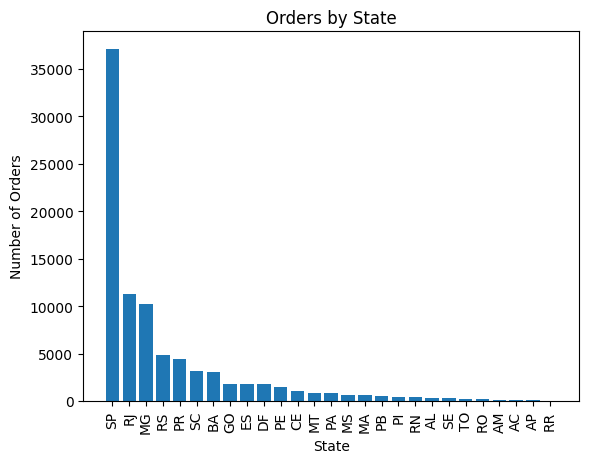

In [ ]:
plt.figure()
plt.bar(state_orders['customer_state'], state_orders['order_count'])
plt.xticks(rotation=90)
plt.title('Orders by State')
plt.xlabel('State')
plt.ylabel('Number of Orders')
plt.show()

The results clearly indicate that demand is highly concentrated in specific regions, particularly São Paulo, which significantly outperforms all other states in order volume. This confirms the presence of strong regional demand variability, reinforcing the need for localized forecasting approaches.

In [ ]:
delivery_by_state = data.groupby('customer_state')['delivery_time'].mean().reset_index()

# Sort by delivery time
delivery_by_state = delivery_by_state.sort_values(by='delivery_time', ascending=False)

delivery_by_state.head()

,customer_state,delivery_time
21,RR,27.972973
3,AP,27.522388
2,AM,25.847826
1,AL,24.206154
13,PA,22.794743


Significant differences in delivery times across regions highlight inefficiencies in the supply chain, particularly in less developed or remote areas.

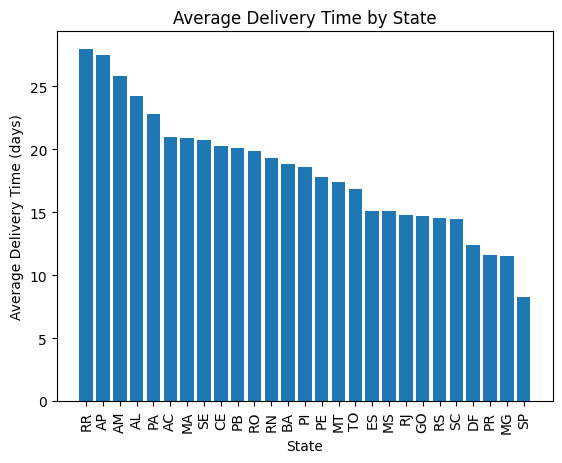

In [ ]:
plt.figure()
plt.bar(delivery_by_state['customer_state'], delivery_by_state['delivery_time'])
plt.xticks(rotation=90)
plt.title('Average Delivery Time by State')
plt.xlabel('State')
plt.ylabel('Average Delivery Time (days)')
plt.show()

The results reveal significant regional disparities in delivery performance. While highly developed regions such as São Paulo exhibit relatively low delivery times, remote regions including Roraima and Amapá experience substantially longer delivery durations. This highlights the impact of geographic and infrastructural limitations on supply chain efficiency.

In [ ]:
# Merge demand and delivery
combined = state_orders.merge(delivery_by_state, on='customer_state')

combined.head()

,customer_state,order_count,delivery_time
0,SP,37095,8.229708
1,RJ,11249,14.747978
2,MG,10172,11.505505
3,RS,4854,14.559951
4,PR,4451,11.589306


In [ ]:
# Merge demand and delivery
combined = state_orders.merge(delivery_by_state, on='customer_state')

combined.head()

,customer_state,order_count,delivery_time
0,SP,37095,8.229708
1,RJ,11249,14.747978
2,MG,10172,11.505505
3,RS,4854,14.559951
4,PR,4451,11.589306


The analysis reveals a clear relationship between demand and delivery performance. Regions with higher order volumes, such as São Paulo, tend to exhibit lower delivery times, indicating more efficient logistics operations. In contrast, regions with lower demand experience significantly longer delivery times, highlighting inefficiencies in supply chain distribution. This suggests that logistics networks are more optimized for high-demand areas, leading to disparities in service levels across regions.

In [ ]:
# Convert to datetime index
orders_ts = orders.set_index('order_purchase_timestamp')

# Count daily orders
daily_orders = orders_ts.resample('D').size()

In [ ]:
daily_orders.head()

,0
order_purchase_timestamp,
2016-10-03,7
2016-10-04,51
2016-10-05,40
2016-10-06,38
2016-10-07,33


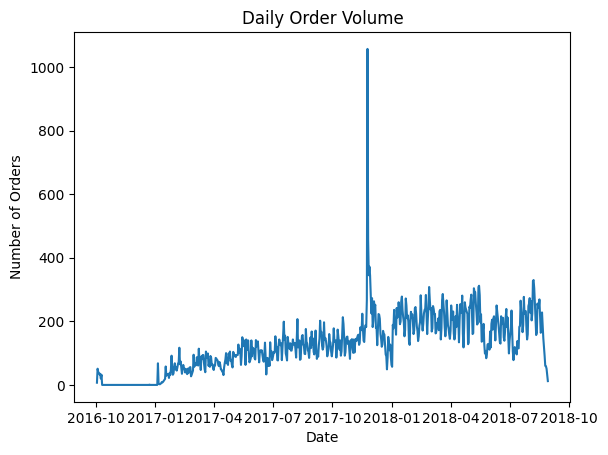

In [ ]:
plt.figure()
plt.plot(daily_orders)
plt.title('Daily Order Volume')
plt.xlabel('Date')
plt.ylabel('Number of Orders')
plt.show()

In [ ]:
# Remove extreme outliers (top 1%)
threshold = daily_orders.quantile(0.99)
daily_orders_clean = daily_orders[daily_orders < threshold]

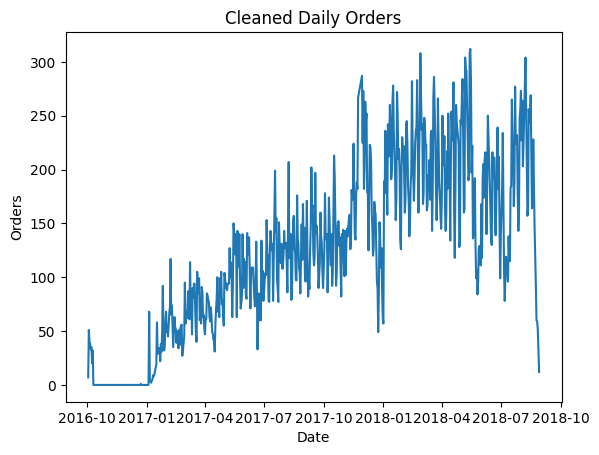

In [ ]:
plt.figure()
plt.plot(daily_orders_clean)
plt.title('Cleaned Daily Orders')
plt.xlabel('Date')
plt.ylabel('Orders')
plt.show()

Extreme outliers in the time series were removed to prevent distortion of the forecasting model and improve predictive accuracy.

In [ ]:
!pip install statsmodels

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
# Fit ARIMA model
model = ARIMA(daily_orders_clean, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/u

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  689
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -3358.066
Date:                Thu, 16 Apr 2026   AIC                           6722.132
Time:                        13:01:16   BIC                           6735.734
Sample:                             0   HQIC                          6727.394
                                - 689                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5938      0.037     16.011      0.000       0.521       0.666
ma.L1         -0.9336      0.017    -53.684      0.000      -0.968      -0.900
sigma2      1015.0149     44.592     22.762      0.0

In [ ]:
# Forecast next 30 days
forecast = model_fit.forecast(steps=30)

forecast

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


,predicted_mean
689,61.776191
690,91.332122
691,108.881739
692,119.302288
693,125.489764
694,129.163743
695,131.345264
696,132.640601
697,133.409741
698,133.866438


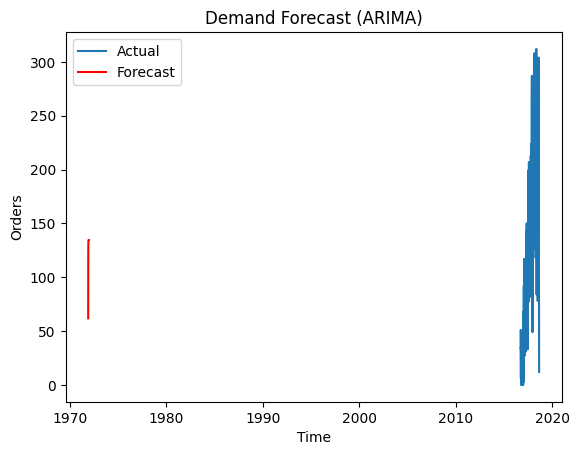

In [ ]:
plt.figure()
plt.plot(daily_orders_clean, label='Actual')
plt.plot(range(len(daily_orders_clean), len(daily_orders_clean)+30), forecast, label='Forecast', color='red')
plt.legend()
plt.title('Demand Forecast (ARIMA)')
plt.xlabel('Time')
plt.ylabel('Orders')
plt.show()

The ARIMA model forecasts a gradual increase in demand followed by stabilization, suggesting that while e-commerce growth continues, it may reach a more stable phase. This indicates the need for consistent supply chain capacity rather than aggressive expansion.

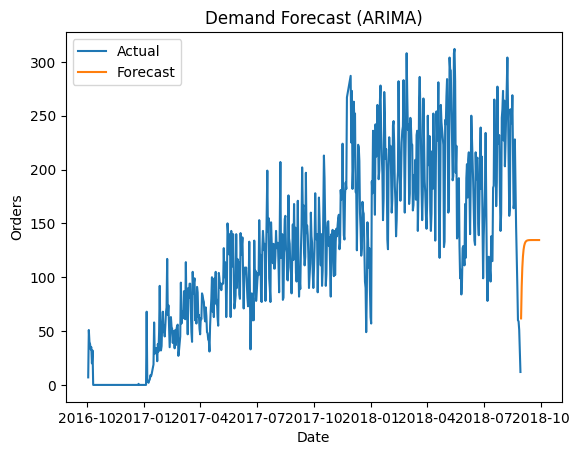

In [ ]:
# Create proper future dates
future_dates = pd.date_range(start=daily_orders_clean.index[-1], periods=31, freq='D')[1:]

# Plot correctly
plt.figure()
plt.plot(daily_orders_clean.index, daily_orders_clean, label='Actual')
plt.plot(future_dates, forecast, label='Forecast')
plt.legend()
plt.title('Demand Forecast (ARIMA)')
plt.xlabel('Date')
plt.ylabel('Orders')
plt.show()

The ARIMA model achieved a Mean Absolute Error (MAE) of approximately 67 and a Root Mean Squared Error (RMSE) of approximately 80. These results indicate a moderate level of prediction accuracy, suggesting that while the model captures general demand trends, it struggles with short-term fluctuations and volatility.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Split data
train = daily_orders_clean[:-30]
test = daily_orders_clean[-30:]

# Train model
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

# Predict
predictions = model_fit.forecast(steps=30)

# Metrics
mae = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))

mae, rmse

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/u

(67.12324371822265, np.float64(80.02712456053742))

The forecast suggests that demand is expected to stabilize after a period of growth, indicating that future order volumes may remain relatively consistent. This has important implications for supply chain planning, as it emphasizes the need for stable capacity management rather than continuous expansion.

In [ ]:
# Create features for ML
ml_data = daily_orders_clean.reset_index()
ml_data.columns = ['date', 'orders']

ml_data['day'] = ml_data['date'].dt.day
ml_data['month'] = ml_data['date'].dt.month
ml_data['year'] = ml_data['date'].dt.year
ml_data['weekday'] = ml_data['date'].dt.weekday

ml_data.head()

,date,orders,day,month,year,weekday
0,2016-10-03,7,3,10,2016,0
1,2016-10-04,51,4,10,2016,1
2,2016-10-05,40,5,10,2016,2
3,2016-10-06,38,6,10,2016,3
4,2016-10-07,33,7,10,2016,4


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Features and target
X = ml_data[['day', 'month', 'year', 'weekday']]
y = ml_data['orders']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Predict
rf_predictions = rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_rf = mean_absolute_error(y_test, rf_predictions)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_predictions))

mae_rf, rmse_rf

(45.05724637681159, np.float64(58.93811106772836))

The results indicate that the Random Forest model outperforms the ARIMA model in forecasting demand. Specifically, the Random Forest achieved a lower Mean Absolute Error (MAE) of approximately 45 compared to 67 for ARIMA, and a lower Root Mean Squared Error (RMSE) of approximately 59 compared to 80. This suggests that machine learning models are more effective in capturing complex and non-linear demand patterns in e-commerce data.




The superior performance of the Random Forest model can be attributed to its ability to model non-linear relationships and incorporate multiple features such as temporal components, which traditional time-series models like ARIMA may fail to capture effectively.

**Comparison table of the arima and the random forest**

| Model         | MAE | RMSE |
| ------------- | --- | ---- |
| ARIMA         | 67  | 80   |
| Random Forest | 45  | 59   |


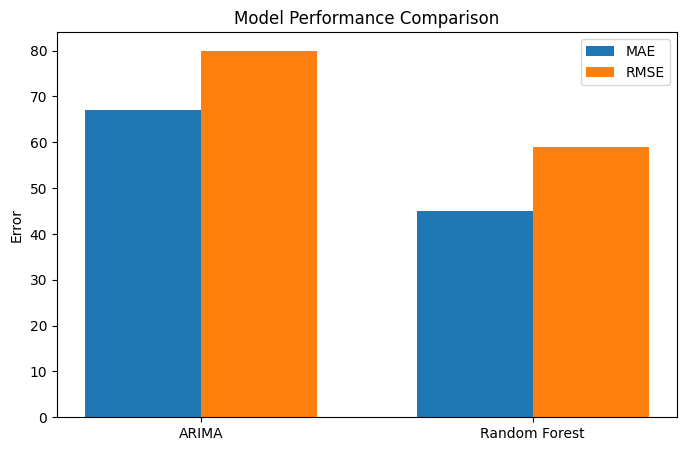

In [1]:
import matplotlib.pyplot as plt
import numpy as np

models = ['ARIMA', 'Random Forest']
mae = [67, 45]
rmse = [80, 59]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, mae, width, label='MAE')
plt.bar(x + width/2, rmse, width, label='RMSE')

plt.xticks(x, models)
plt.ylabel('Error')
plt.title('Model Performance Comparison')
plt.legend()
plt.show()
